# CNN Model for Respiratory Disease Classification

Train a CNN on cycle-level spectrograms and evaluate at patient level with probability aggregation.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

Using device: cpu


## 1) Load Metadata and Verify Spectrogram Paths
Load processed_audio/metadata.csv, verify required columns and spectrogram paths, and split by `split`.

In [2]:
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'processed_audio').exists() else cwd.parent
metadata_path = project_root / 'processed_audio' / 'metadata.csv'

if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')

df = pd.read_csv(metadata_path)
required_cols = ['patient_id', 'spectrogram_path', 'diagnosis', 'split']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df = df.copy()
df['diagnosis'] = df['diagnosis'].astype(str).str.strip()
df['split'] = df['split'].astype(str)
df['spectrogram_path'] = df['spectrogram_path'].astype(str)
df = df[df['diagnosis'] != '']

df['spec_path_abs'] = df['spectrogram_path'].map(lambda p: project_root / str(p))
missing_paths = df[~df['spec_path_abs'].map(lambda p: p.exists())]
if not missing_paths.empty:
    raise FileNotFoundError(
        f"Missing spectrogram files. Examples: {missing_paths['spectrogram_path'].head(5).tolist()}"
    )

splits = ['train', 'validation', 'test']
df_splits = {s: df[df['split'] == s].copy() for s in splits}
for s in splits:
    if df_splits[s].empty:
        raise ValueError(f'No samples found for split: {s}')

split_counts = df[['patient_id', 'split']].drop_duplicates().groupby('patient_id')['split'].nunique()
leaky_patients = split_counts[split_counts > 1]
print('Patients appearing in multiple splits:', len(leaky_patients))
if len(leaky_patients) > 0:
    display(leaky_patients.head(10))

print('Train/Val/Test sizes:', {k: len(v) for k, v in df_splits.items()})

Patients appearing in multiple splits: 0
Train/Val/Test sizes: {'train': 4503, 'validation': 1288, 'test': 1107}


## 2) Encode Diagnosis Labels and Save Mapping
Fit a label encoder and store the label ↔ index mapping.

In [3]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diagnosis'])
label_mapping = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
inv_label_mapping = {int(idx): label for label, idx in label_mapping.items()}
# Refresh split views now that labels exist
df_splits = {s: df[df['split'] == s].copy() for s in splits}
display(pd.DataFrame({'label': list(label_mapping.keys()), 'index': list(label_mapping.values())}))

,label,index
0,Bronchiectasis,0
1,Bronchiolitis,1
2,COPD,2
3,Healthy,3
4,Other,4
5,Pneumonia,5
6,URTI,6


## 3) Define PyTorch Dataset for Spectrograms
Load .npy spectrograms, cast to float32, and ensure shape [1, 128, 128].

In [4]:
class SpectrogramDataset(Dataset):
    def __init__(self, df_split: pd.DataFrame):
        self.df = df_split.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.load(row['spec_path_abs'], allow_pickle=False).astype(np.float32)
        if arr.shape == (128, 128):
            arr = np.expand_dims(arr, axis=0)
        if arr.shape != (1, 128, 128):
            raise ValueError(f'Unexpected spectrogram shape: {arr.shape}')
        x = torch.from_numpy(arr)
        y = int(row['label'])
        return x, y

## 4) Create DataLoaders
Build DataLoaders with batch_size=32 and shuffle only for training.

In [5]:
batch_size = 32

train_ds = SpectrogramDataset(df_splits['train'])
val_ds = SpectrogramDataset(df_splits['validation'])
test_ds = SpectrogramDataset(df_splits['test'])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print('Batches (train/val/test):', len(train_loader), len(val_loader), len(test_loader))

Batches (train/val/test): 141 41 35


## 5) Define CNN Model Architecture
Conv → ReLU → MaxPool blocks, then FC layers and dropout.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = len(label_encoder.classes_)
model = SimpleCNN(num_classes).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


## 6) Compute Class Weights
Weights inversely proportional to class frequency (training set).

In [7]:
train_labels = df_splits['train']['label'].values
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = class_counts.sum() / np.clip(class_counts, a_min=1, a_max=None)
class_weights = class_weights / class_weights.sum() * num_classes
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
display(pd.DataFrame({'class': label_encoder.classes_, 'count': class_counts, 'weight': class_weights}))

,class,count,weight
0,Bronchiectasis,90,1.120447
1,Bronchiolitis,114,0.884563
2,COPD,3672,0.027462
3,Healthy,228,0.442282
4,Other,30,3.361341
5,Pneumonia,230,0.438436
6,URTI,139,0.725469


## 7) Configure Loss and Optimizer
CrossEntropyLoss with class weights and Adam optimizer.

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 8) Training Loop with Validation
Train for 20 epochs and evaluate on the validation set each epoch.

In [9]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_preds = []
    all_labels = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1

epochs = 20
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, epochs + 1):
    train_loss, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, optimizer=None)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f}"
    )

Epoch 01/20 | train_loss=1.8390 | val_loss=1.6015 | val_acc=0.1483 | val_f1=0.0716
Epoch 02/20 | train_loss=1.6281 | val_loss=1.0803 | val_acc=0.7857 | val_f1=0.1629
Epoch 03/20 | train_loss=1.3893 | val_loss=1.3979 | val_acc=0.4526 | val_f1=0.1703
Epoch 04/20 | train_loss=1.1995 | val_loss=1.4591 | val_acc=0.3703 | val_f1=0.1366
Epoch 05/20 | train_loss=1.1230 | val_loss=1.2743 | val_acc=0.5520 | val_f1=0.1713
Epoch 06/20 | train_loss=1.0287 | val_loss=1.2996 | val_acc=0.5016 | val_f1=0.1786
Epoch 07/20 | train_loss=0.9268 | val_loss=1.1523 | val_acc=0.5916 | val_f1=0.1945
Epoch 08/20 | train_loss=0.8228 | val_loss=1.1153 | val_acc=0.6561 | val_f1=0.2138
Epoch 09/20 | train_loss=0.7566 | val_loss=1.3122 | val_acc=0.5784 | val_f1=0.1784
Epoch 10/20 | train_loss=0.6734 | val_loss=1.4971 | val_acc=0.4573 | val_f1=0.1710
Epoch 11/20 | train_loss=0.6122 | val_loss=1.2932 | val_acc=0.6258 | val_f1=0.1734
Epoch 12/20 | train_loss=0.5230 | val_loss=1.3723 | val_acc=0.5908 | val_f1=0.1817
Epoc

## 9) Validation Metrics per Epoch
Track validation accuracy and macro F1 to monitor overfitting.

In [10]:
val_metrics_df = pd.DataFrame({
    'epoch': list(range(1, epochs + 1)),
    'val_loss': history['val_loss'],
    'val_acc': history['val_acc'],
    'val_f1': history['val_f1'],
})
display(val_metrics_df.tail(5))

,epoch,val_loss,val_acc,val_f1
15,16,1.481620,0.698758,0.188785
16,17,1.655011,0.662267,0.192333
17,18,1.411629,0.762422,0.206789
18,19,1.777586,0.666925,0.188394
19,20,1.533586,0.739130,0.213988


## 10) Predict Cycle-Level Probabilities
Run the trained model on the test set to get per-cycle probabilities.

In [11]:
model.eval()
all_probs = []
all_true = []
all_pids = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.append(y.numpy())
    
all_probs = np.vstack(all_probs)
all_true = np.concatenate(all_true)
all_pids = df_splits['test']['patient_id'].values
test_cycle_df = pd.DataFrame(all_probs, columns=label_encoder.classes_)
test_cycle_df['patient_id'] = all_pids
test_cycle_df['true_label'] = label_encoder.inverse_transform(all_true)
test_cycle_df.head()

,Bronchiectasis,Bronchiolitis,COPD,Healthy,Other,Pneumonia,URTI,patient_id,true_label
0,4.672539e-03,0.016559,0.408520,0.180865,0.232121,5.666376e-02,0.100599,102,Healthy
1,8.368558e-02,0.042815,0.282076,0.416466,0.104933,1.358542e-03,0.068667,102,Healthy
2,1.517169e-04,0.000193,0.000821,0.003467,0.000025,1.282585e-08,0.995343,102,Healthy
3,8.920533e-07,0.020483,0.000043,0.000036,0.000050,7.422734e-09,0.979386,102,Healthy
4,2.022296e-04,0.077163,0.001224,0.009154,0.049360,6.602380e-05,0.862831,102,Healthy


## 11) Aggregate to Patient-Level Predictions
Average per-cycle probabilities by patient_id and pick the top class.

In [12]:
patient_probs = test_cycle_df.groupby('patient_id')[label_encoder.classes_].mean()
patient_true = test_cycle_df.groupby('patient_id')['true_label'].agg(lambda x: x.iloc[0])
patient_pred = patient_probs.idxmax(axis=1)

patient_results = pd.DataFrame({
    'patient_id': patient_probs.index,
    'true_label': patient_true.values,
    'pred_label': patient_pred.values,
    'max_confidence': patient_probs.max(axis=1).values
})
patient_results.head()

,patient_id,true_label,pred_label,max_confidence
0,102,Healthy,URTI,0.581057
1,105,URTI,Bronchiectasis,0.962140
2,107,COPD,COPD,0.826011
3,116,Bronchiectasis,Pneumonia,0.403291
4,121,Healthy,Healthy,0.561063


## 12) Evaluate Patient-Level Performance
Compute accuracy, precision, recall, macro F1, and confusion matrix.

In [13]:
y_true = patient_results['true_label'].values
y_pred = patient_results['pred_label'].values

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
 )
cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)

print('Patient-level accuracy:', acc)
print('Patient-level precision (macro):', precision)
print('Patient-level recall (macro):', recall)
print('Patient-level F1 (macro):', f1)

Patient-level accuracy: 0.5555555555555556
Patient-level precision (macro): 0.3666666666666667
Patient-level recall (macro): 0.3796296296296296
Patient-level F1 (macro): 0.31249999999999994


## 13) Visualize Training Curves
Plot training loss, validation loss, and validation macro F1 per epoch.

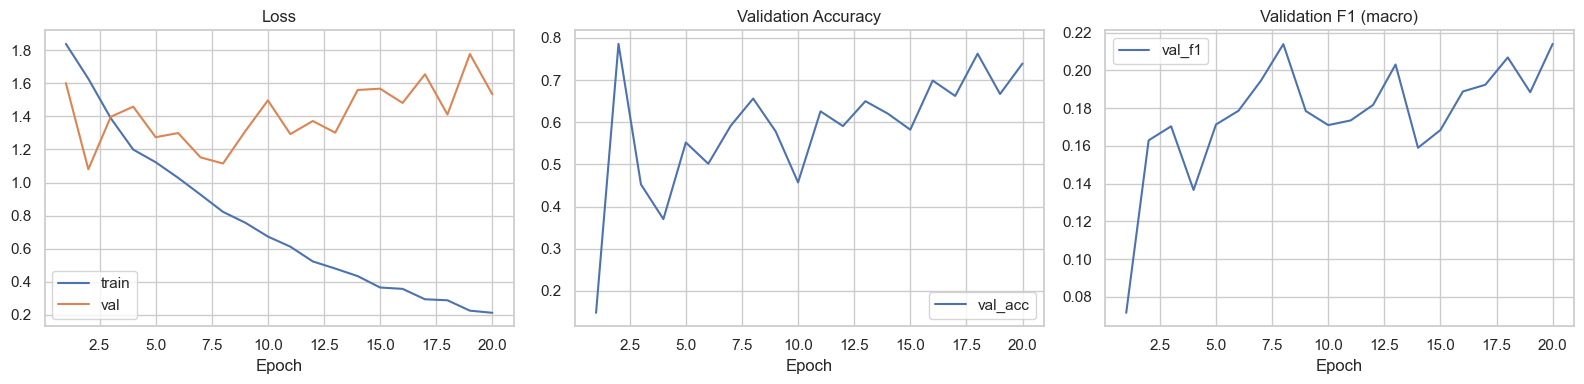

In [14]:
epochs_range = range(1, epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], label='train')
axes[0].plot(epochs_range, history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], label='val_acc')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_range, history['val_f1'], label='val_f1')
axes[2].set_title('Validation F1 (macro)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 14) Visualize Evaluation Metrics
Plot confusion matrices and class-wise F1 scores.

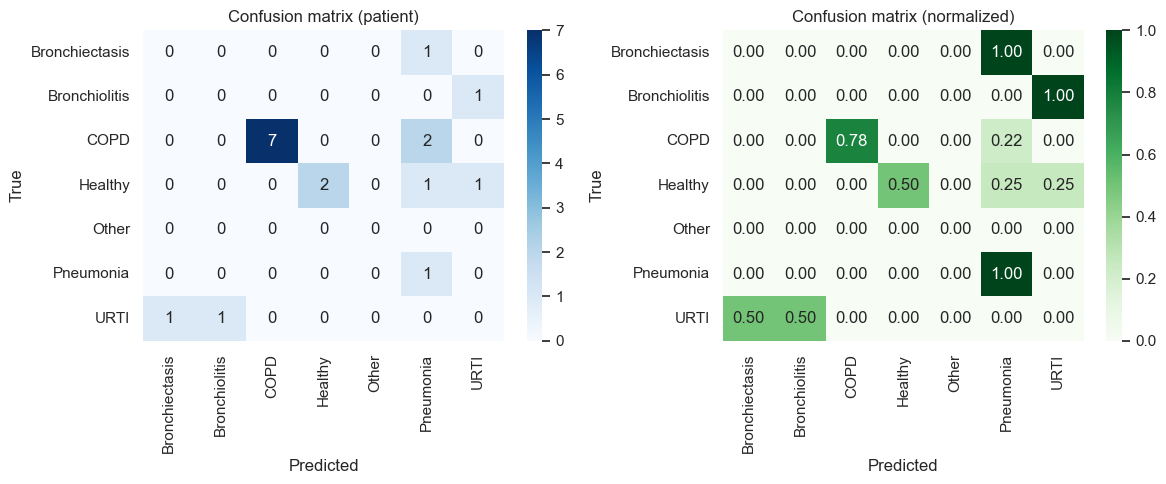

/Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


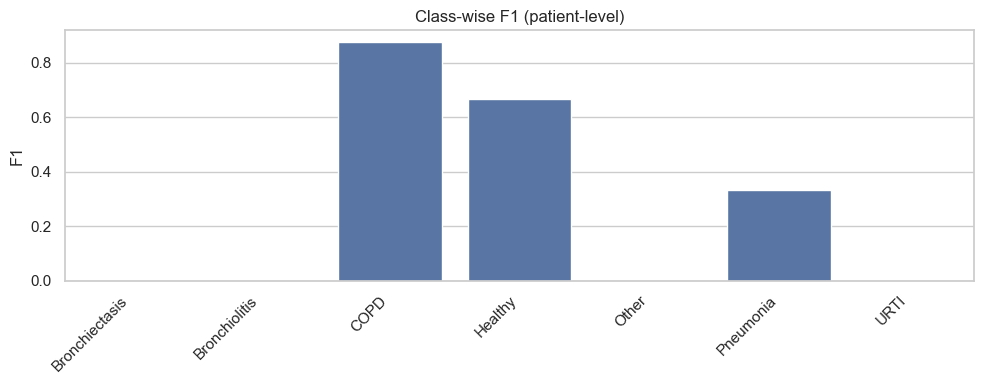

In [15]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Confusion matrix (patient)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Confusion matrix (normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

class_f1 = f1_score(y_true, y_pred, average=None, labels=label_encoder.classes_)
plt.figure(figsize=(10, 4))
sns.barplot(x=label_encoder.classes_, y=class_f1)
plt.title('Class-wise F1 (patient-level)')
plt.ylabel('F1')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 15) Error Analysis: Misclassified Patients
List misclassified patients and optionally visualize their spectrograms.

Misclassified patients: 8
Misclassified patients percentage: 44.44444444444444


,patient_id,true_label,pred_label,max_confidence
0,102,Healthy,URTI,0.581057
1,105,URTI,Bronchiectasis,0.962140
3,116,Bronchiectasis,Pneumonia,0.403291
6,134,COPD,Pneumonia,0.653773
7,136,Healthy,Pneumonia,0.916335
10,161,Bronchiolitis,URTI,0.386281
12,188,URTI,Bronchiolitis,0.532527
15,192,COPD,Pneumonia,0.702731


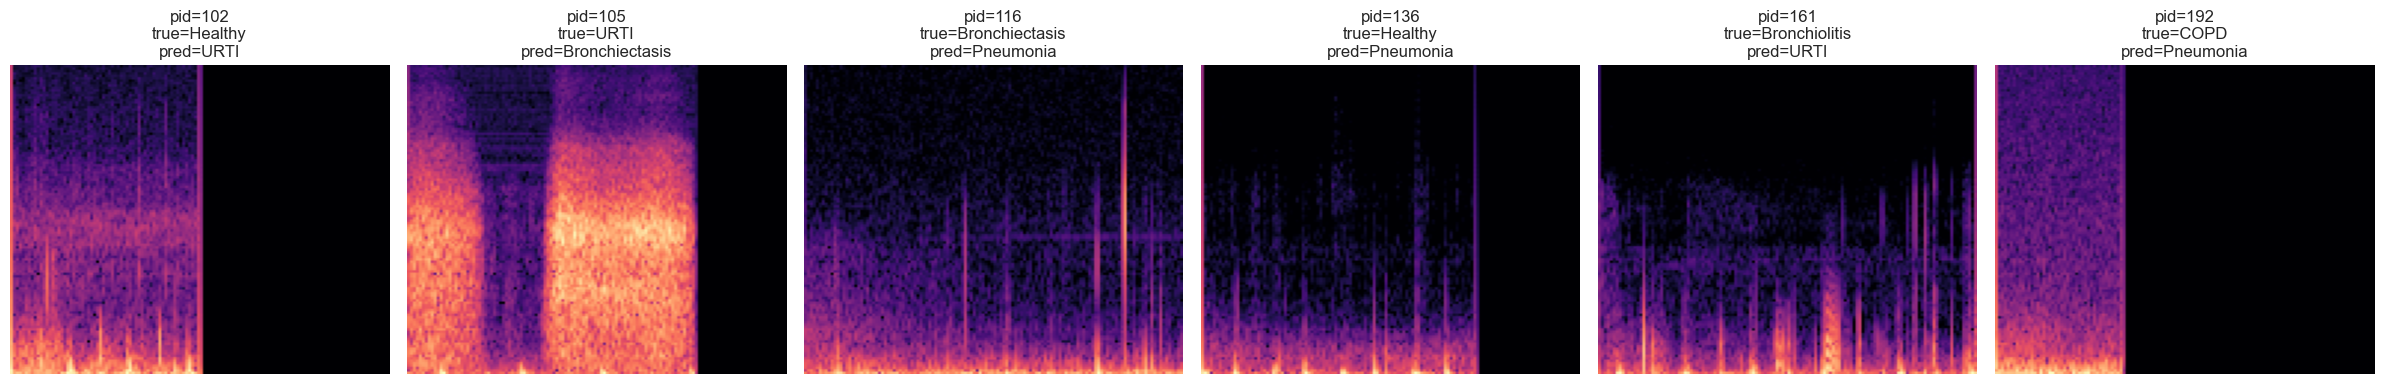

In [16]:
mis_patients = patient_results[patient_results['true_label'] != patient_results['pred_label']].copy()
print('Misclassified patients:', len(mis_patients))
print('Misclassified patients percentage:', len(mis_patients) / len(patient_results) * 100)
display(mis_patients.head(20))

show_error_specs = True
if show_error_specs and len(mis_patients) > 0:
    sample_pids = mis_patients.sample(min(6, len(mis_patients)), random_state=SEED)['patient_id'].tolist()
    rows = df_splits['test'][df_splits['test']['patient_id'].isin(sample_pids)].copy()
    rows = rows.groupby('patient_id').head(1).reset_index(drop=True)
    fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        arr = np.load(row['spec_path_abs'], allow_pickle=False)
        ax.imshow(arr, origin='lower', aspect='auto', cmap='magma')
        pred = mis_patients.loc[mis_patients['patient_id'] == row['patient_id'], 'pred_label'].iloc[0]
        ax.set_title(f"pid={row['patient_id']}\ntrue={row['diagnosis']}\npred={pred}")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()